설치/임포트

In [1]:
# 필요 시 설치(노트북 커널 기준)
# uv 환경이면 터미널에서: uv pip install umap-learn hdbscan scikit-learn matplotlib fastparquet
# 노트북에서 pip가 동작하면: %pip install umap-learn hdbscan scikit-learn matplotlib fastparquet

import os
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap
import hdbscan

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

c:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


경로 설정

In [2]:
from pathlib import Path

cwd = Path(os.getcwd()).resolve()

def find_project_root(start: Path, max_up: int = 6) -> Path:
    cur = start
    for _ in range(max_up):
        if (cur / "data" / "processed").exists():
            return cur
        cur = cur.parent
    return start.parent

PROJECT_ROOT = find_project_root(cwd)

IN_PATH = PROJECT_ROOT / "data" / "processed" / "pitch_clean.parquet"
OUT_DIR = PROJECT_ROOT / "data" / "processed"

OUT_PITCH = OUT_DIR / "pitch_umap_cluster.parquet"
OUT_SUMMARY = OUT_DIR / "pitcher_cluster_summary.csv"

print("CWD:", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("IN_PATH:", IN_PATH, "exists?", IN_PATH.exists())
print("OUT_PITCH:", OUT_PITCH)
print("OUT_SUMMARY:", OUT_SUMMARY)

CWD: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\notebooks
PROJECT_ROOT: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess
IN_PATH: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\data\processed\pitch_clean.parquet exists? True
OUT_PITCH: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\data\processed\pitch_umap_cluster.parquet
OUT_SUMMARY: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\data\processed\pitcher_cluster_summary.csv


데이터 로드

In [3]:
df = pd.read_parquet(IN_PATH)
print("loaded:", df.shape)
df.head(3)

loaded: (721038, 36)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,batter,pitcher,events,description,zone,...,launch_angle,release_spin_rate,release_extension,pitch_number,bat_score_diff,arm_angle,description_group,events_group,base_state,count
0,FF,2025-03-19,92.8,0.11,5.98,807713,681911,field_out,hit_into_play,3.0,...,-18.0,2526.0,6.4,2,-3,71.0,inplay,out,3,0-1
1,SL,2025-03-19,83.5,0.31,6.18,807713,681911,NaN,called_strike,1.0,...,0.0,2465.0,6.3,1,-3,66.9,strike,other,3,0-0
2,FF,2025-03-19,92.6,0.22,6.00,457759,681911,walk,ball,12.0,...,0.0,2532.0,6.4,5,-3,62.3,ball,walk,2,3-1


UMAP 입력 feature 확인 + 정리

In [4]:
PITCH_FEATURES_FOR_UMAP = [
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "arm_angle",
]

need_cols = ["pitcher"] + PITCH_FEATURES_FOR_UMAP
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# 마지막 안전 dropna (UMAP/HDBSCAN NaN 불가)
before = len(df)
df = df.dropna(subset=need_cols).copy()
after = len(df)
print(f"dropna: {before:,} -> {after:,}")

df["pitcher"] = pd.to_numeric(df["pitcher"], errors="coerce").astype(int)

dropna: 721,038 -> 721,038


파라미터 설정

In [5]:
# 너무 적으면 UMAP도 의미가 약해서 스킵(시간 절약 + 쓰레기 결과 방지)
MIN_PITCHES_FOR_UMAP = 40

# 클러스터링(라벨 생성)은 표본이 더 필요하므로 더 높은 컷
MIN_PITCHES_FOR_CLUSTER = 120

# UMAP
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS = 2
UMAP_RANDOM_STATE = 42

# PCA → UMAP (안정성/속도)
USE_PCA = True
PCA_N_COMPONENTS = 6

# HDBSCAN 기본값(표본 많을 때)
HDB_MIN_CLUSTER_SIZE_DEFAULT = 60
HDB_MIN_SAMPLES_DEFAULT = 15

# (선택) 처음 디버깅용으로 투수 수 제한 가능
LIMIT_PITCHERS = None  # 예: 50 / 전체는 None

투수 목록(전부 포함) + 스킵 대상 확인

In [6]:
pitch_counts = df.groupby("pitcher").size().sort_values(ascending=False)

all_pitchers = pitch_counts.index.tolist()
if LIMIT_PITCHERS is not None:
    all_pitchers = all_pitchers[:LIMIT_PITCHERS]

total_pitchers = len(all_pitchers)
print("total pitchers in df:", pitch_counts.shape[0])
print("processing pitchers:", total_pitchers)

n_under_umap = int((pitch_counts < MIN_PITCHES_FOR_UMAP).sum())
n_under_cluster = int(((pitch_counts >= MIN_PITCHES_FOR_UMAP) & (pitch_counts < MIN_PITCHES_FOR_CLUSTER)).sum())

print(f"pitchers < {MIN_PITCHES_FOR_UMAP} (UMAP skip):", n_under_umap)
print(f"pitchers in [{MIN_PITCHES_FOR_UMAP}, {MIN_PITCHES_FOR_CLUSTER}) (UMAP ok, clustering skip):", n_under_cluster)

pitch_counts.head(10)

total pitchers in df: 872
processing pitchers: 872
pitchers < 40 (UMAP skip): 73
pitchers in [40, 120) (UMAP ok, clustering skip): 92


pitcher
592332    3466
607074    3363
642547    3362
808967    3315
657277    3282
608331    3262
676979    3241
669373    3152
668678    3134
666200    3120
dtype: int64

HDBSCAN 파라미터를 “투구 수에 따라” 자동 결정하는 함수

In [7]:
def adaptive_hdbscan_params(n_pitches: int):
    """
    표본 수가 적을수록 min_cluster_size / min_samples를 줄여야
    전부 -1(noise) 되는 걸 줄일 수 있습니다.
    """
    if n_pitches < MIN_PITCHES_FOR_CLUSTER:
        return None  # clustering skip

    # 표본이 적으면 클러스터 최소 크기를 n의 일정 비율로 낮춤
    # 너무 낮아지지 않도록 하한/상한 설정
    min_cluster_size = int(max(15, min(HDB_MIN_CLUSTER_SIZE_DEFAULT, n_pitches * 0.10)))  # 10%
    min_samples = int(max(5, min(HDB_MIN_SAMPLES_DEFAULT, min_cluster_size // 2)))

    return min_cluster_size, min_samples

전 투수 UMAP + (가능한 경우) 클러스터링

In [8]:
results = []
summary_rows = []

t0 = time.time()

for idx, pid in enumerate(all_pitchers, start=1):
    sub = df[df["pitcher"] == pid].copy()
    n = len(sub)

    # 너무 적으면 스킵(결과 테이블에 남기지 않으면, 이후 프로필도 못 만듦)
    # "전 투수 포함"이 목표이므로: 스킵하지 말고, 최소한 summary에는 남기고,
    # pitch-level은 저장하지 않는 방식으로 처리합니다.
    if n < MIN_PITCHES_FOR_UMAP:
        summary_rows.append({
            "pitcher": int(pid),
            "n_pitches": int(n),
            "did_umap": 0,
            "did_cluster": 0,
            "n_clusters": 0,
            "noise_ratio": np.nan,
            "note": f"UMAP skipped (<{MIN_PITCHES_FOR_UMAP})"
        })
        if idx % 50 == 0 or idx == 1 or idx == total_pitchers:
            print(f"[{idx}/{total_pitchers}] pitcher={pid} skipped (n={n})")
        continue

    X = sub[PITCH_FEATURES_FOR_UMAP].to_numpy(dtype=float)

    # 1) scaling (투수별 기준)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # 2) PCA (선택)
    if USE_PCA:
        n_comp = min(PCA_N_COMPONENTS, Xs.shape[1])
        pca = PCA(n_components=n_comp, random_state=UMAP_RANDOM_STATE)
        X_in = pca.fit_transform(Xs)
    else:
        X_in = Xs

    # 3) UMAP
    reducer = umap.UMAP(
        n_neighbors=min(UMAP_N_NEIGHBORS, max(5, n - 1)),  # 표본 적을 때 neighbors 자동 축소
        min_dist=UMAP_MIN_DIST,
        n_components=UMAP_N_COMPONENTS,
        random_state=UMAP_RANDOM_STATE,
    )
    emb = reducer.fit_transform(X_in)

    sub["umap_x"] = emb[:, 0]
    sub["umap_y"] = emb[:, 1]

    # 4) clustering (표본 충분할 때만)
    params = adaptive_hdbscan_params(n)

    if params is None:
        # clustering skip
        labels = np.full(shape=(n,), fill_value=-1, dtype=int)
        did_cluster = 0
        n_clusters = 0
        noise_ratio = 1.0
        note = f"Clustering skipped (<{MIN_PITCHES_FOR_CLUSTER})"
    else:
        min_cluster_size, min_samples = params
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
        )
        labels = clusterer.fit_predict(emb)
        did_cluster = 1
        n_clusters = int(np.unique(labels[labels != -1]).shape[0])
        noise_ratio = float(np.mean(labels == -1))
        note = f"HDBSCAN(min_cluster_size={min_cluster_size}, min_samples={min_samples})"

    sub["pitch_cluster_local"] = labels

    # 투수별 라벨 충돌 방지용 전역 ID
    sub["pitch_cluster_id"] = sub["pitcher"].astype(str) + "_" + sub["pitch_cluster_local"].astype(str)

    results.append(sub)

    # 요약
    row = {
        "pitcher": int(pid),
        "n_pitches": int(n),
        "did_umap": 1,
        "did_cluster": int(did_cluster),
        "n_clusters": int(n_clusters),
        "noise_ratio": float(noise_ratio),
        "note": note
    }

    # 상위 클러스터 비중(클러스터링 수행한 경우만)
    if did_cluster:
        vc = pd.Series(labels).value_counts()
        top = vc[vc.index != -1].head(8)
        for k, v in top.items():
            row[f"local_cluster_{int(k)}_ratio"] = float(v / n)

    summary_rows.append(row)

    if idx % 25 == 0 or idx == 1 or idx == total_pitchers:
        elapsed = time.time() - t0
        print(f"[{idx}/{total_pitchers}] pitcher={pid} done (n={n}) | elapsed={elapsed:.1f}s")

# pitch-level 결과는 UMAP 수행한 투수만 합쳐짐
df_out = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
summary = pd.DataFrame(summary_rows)

print("df_out:", df_out.shape)
print("summary:", summary.shape)
summary.head(10)

[1/872] pitcher=592332 done (n=3466) | elapsed=26.6s
[25/872] pitcher=571510 done (n=2899) | elapsed=393.4s
[50/872] pitcher=671106 done (n=2630) | elapsed=695.5s
[75/872] pitcher=607200 done (n=2369) | elapsed=954.4s
[100/872] pitcher=608566 done (n=2085) | elapsed=1158.3s
[125/872] pitcher=477132 done (n=1742) | elapsed=1313.0s
[150/872] pitcher=693645 done (n=1448) | elapsed=1431.8s
[175/872] pitcher=663574 done (n=1258) | elapsed=1523.9s
[200/872] pitcher=676879 done (n=1188) | elapsed=1605.5s
[225/872] pitcher=670280 done (n=1103) | elapsed=1682.0s
[250/872] pitcher=641941 done (n=1066) | elapsed=1752.1s
[275/872] pitcher=695243 done (n=1011) | elapsed=1818.0s
[300/872] pitcher=547973 done (n=957) | elapsed=1879.2s
[325/872] pitcher=683232 done (n=882) | elapsed=1935.8s
[350/872] pitcher=668984 done (n=812) | elapsed=1985.9s
[375/872] pitcher=690916 done (n=735) | elapsed=2030.2s
[400/872] pitcher=829272 done (n=674) | elapsed=2069.7s
[425/872] pitcher=687863 done (n=624) | elapse

,pitcher,n_pitches,did_umap,did_cluster,n_clusters,noise_ratio,note,local_cluster_0_ratio,local_cluster_2_ratio,local_cluster_1_ratio,local_cluster_3_ratio,local_cluster_7_ratio,local_cluster_5_ratio,local_cluster_6_ratio,local_cluster_4_ratio,local_cluster_13_ratio,local_cluster_10_ratio,local_cluster_8_ratio,local_cluster_9_ratio,local_cluster_11_ratio
0,592332,3466,1,1,3,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.526832,0.382574,0.090594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,607074,3363,1,1,8,0.002379,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.036574,0.164139,0.281594,0.156705,0.135296,0.098424,0.093369,0.031519,NaN,NaN,NaN,NaN,NaN
2,642547,3362,1,1,3,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.212374,0.261154,0.526472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,808967,3315,1,1,5,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.258220,0.139367,0.184314,0.161086,NaN,NaN,NaN,0.257014,NaN,NaN,NaN,NaN,NaN
4,657277,3282,1,1,5,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.265996,0.135588,0.102072,0.156612,NaN,NaN,NaN,0.339732,NaN,NaN,NaN,NaN,NaN
5,608331,3262,1,1,5,0.000613,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.173820,0.421827,0.116493,0.110975,NaN,NaN,NaN,0.176272,NaN,NaN,NaN,NaN,NaN
6,676979,3241,1,1,4,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.019438,0.160753,0.543042,0.276766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,669373,3152,1,1,7,0.000317,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.027284,0.389277,0.128490,0.139911,NaN,0.074873,0.070749,0.169099,NaN,NaN,NaN,NaN,NaN
8,668678,3134,1,1,4,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.160179,0.127632,0.235801,0.476388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,666200,3120,1,1,3,0.000000,"HDBSCAN(min_cluster_size=60, min_samples=15)",0.388141,0.437179,0.174679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


저장

In [9]:
# 01에서 parquet 저장이 되었으니 일단 기본 엔진으로 저장 시도
# 문제가 있으면 engine="fastparquet"로 바꾸면 됩니다.
df_out.to_parquet(OUT_PITCH, index=False)
summary.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")

print("saved:", OUT_PITCH)
print("saved:", OUT_SUMMARY)

saved: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\data\processed\pitch_umap_cluster.parquet
saved: C:\Users\Dalab-server\Documents\kangmin\Pitcheezy\data_preprocess\data\processed\pitcher_cluster_summary.csv


결과 검증: 특정 투수 UMAP 시각화

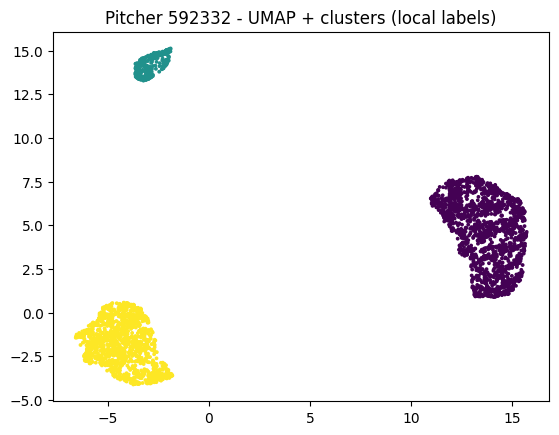

pitch_cluster_local
0    1826
2    1326
1     314
Name: count, dtype: int64

In [10]:
# UMAP 수행된 투수 중 하나 골라보기: 투구 많은 투수 1명
valid_pitchers = summary[(summary["did_umap"] == 1)]["pitcher"].astype(int).tolist()
pid = int(valid_pitchers[0])

tmp = df_out[df_out["pitcher"] == pid].copy()

plt.figure()
plt.scatter(tmp["umap_x"], tmp["umap_y"], s=3, c=tmp["pitch_cluster_local"])
plt.title(f"Pitcher {pid} - UMAP + clusters (local labels)")
plt.show()

tmp["pitch_cluster_local"].value_counts().head(15)